# Project 03 · Notebook 03 — Costed Long-Short Backtest & Deflated Sharpe

Notebook 02 found three weak, nearly-uncorrelated price factors and showed a *naïve* equal-weight
composite loses. The obvious next move a researcher tries: **combine the factors intelligently** —
weight each by how well it has *recently* predicted returns (rolling IC), which also flips any
wrong-sign factor automatically. Then charge realistic costs and apply the honest test battery.

The deliverable is a **verdict, not a curve**: does *any* of these constructions survive turnover
costs and a **deflated Sharpe** after accounting for the factors/configs we searched?

**Three books, all dollar-neutral quintile long-short, rebalanced monthly:**
1. `momentum_only` — the best single factor from nb02.
2. `equal_composite` — naïve equal-weight of the three z-scores.
3. `ic_weighted` — sign-aware, **look-ahead-free** rolling-IC weights (`src/factors.py`).

> **No look-ahead.** A factor's IC at month *t* is only known at *t+1* (it uses the *t→t+1* forward
> return), so weights are lagged one month (`rolling_ic_weights` does the `shift(1)`). Survivorship
> bias from nb01 still makes every number here an optimistic upper bound.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "03_equity_factor_xsection"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(PROJ / "src"))

from dataset import load_adj_close, load_universe
from factors import (build_price_factors, neutralize, rank_ic, ls_stats,
                     rolling_ic_weights, combine_signals, long_short_book)
from lib.backtest import sharpe_ratio, probabilistic_sharpe_ratio, deflated_sharpe_ratio

plt.rcParams["figure.figsize"] = (10, 4)
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## 1. Rebuild factors and per-factor IC (from nb02)

In [2]:
px = load_adj_close()
uni = load_universe().set_index("symbol"); sector = uni["sector"].reindex(px.columns)
me = px.resample("ME").last(); mret = me.pct_change(); fwd = mret.shift(-1)
mask = pd.read_parquet(PROJ / "data" / "panel" / "tradable_mask.parquet")
mask.index = pd.to_datetime(mask.index)

raw = build_price_factors(px, me, mret)
neutral = {k: neutralize(v, mask, sector) for k, v in raw.items()}
ic = pd.DataFrame({k: rank_ic(v, fwd) for k, v in neutral.items()}).reindex(me.index)
print("factors:", list(neutral), "| IC months:", ic.dropna(how='all').shape[0])

factors: ['mom_12_1', 'reversal_1m', 'low_vol'] | IC months: 178


## 2. Sign-aware combination without look-ahead

`rolling_ic_weights` lags the IC by one month and takes a 24-month trailing mean, so each month's
weights only use information available *before* that month. A negative trailing IC (e.g. low-vol in
this sample) automatically flips that factor's contribution.

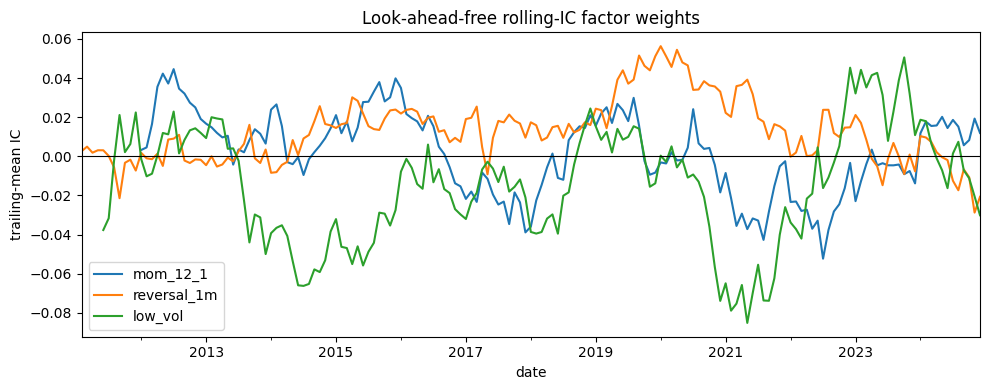

last weights: {'mom_12_1': 0.012, 'reversal_1m': -0.021, 'low_vol': -0.03}


In [3]:
weights = rolling_ic_weights(ic, lookback=24, min_periods=12)
combo = combine_signals(neutral, weights)
ew_composite = sum(neutral.values()) / len(neutral)

fig, ax = plt.subplots()
weights.dropna(how="all").plot(ax=ax)
ax.axhline(0, color="k", lw=0.8)
ax.set(title="Look-ahead-free rolling-IC factor weights", xlabel="date", ylabel="trailing-mean IC")
plt.tight_layout()
plt.savefig(PLOTS / "03_ic_weights.png", dpi=110, bbox_inches="tight"); plt.show()
print("last weights:", weights.dropna(how="all").iloc[-1].round(3).to_dict())

## 3. Costed long-short books

Quintile (top-20% vs bottom-20%) dollar-neutral books, equal-weight legs, charged `cost_per_side`
per unit of two-sided turnover. We sweep 5 / 10 / 20 bps to see how quickly the thin gross edge is
eaten.

In [4]:
books = {"momentum_only": neutral["mom_12_1"], "equal_composite": ew_composite, "ic_weighted": combo}

rows = []
for name, fz in books.items():
    for c in (0.0005, 0.0010, 0.0020):
        bk = long_short_book(fz, fwd, q=0.2, cost_per_side=c)
        s = ls_stats(bk["net"])
        rows.append({"book": name, "cost_bps": int(c * 1e4),
                     "gross_ann_%": ls_stats(bk["gross"])["ann_return"] * 100,
                     "net_ann_%": s["ann_return"] * 100, "net_sharpe": s["sharpe"],
                     "net_t": s["t_stat"], "avg_turnover": bk["turnover"].mean()})
sweep = pd.DataFrame(rows).set_index(["book", "cost_bps"])
sweep.round(2)

gross_ann_%  net_ann_%  net_sharpe   net_t  \
book            cost_bps                                               
momentum_only   5              0.5900    -0.0600     -0.0100 -0.0200   
                10             0.5900    -0.7100     -0.0600 -0.2400   
                20             0.5900    -2.0200     -0.1800 -0.6900   
equal_composite 5             -1.1900    -2.6000     -0.2500 -0.9400   
                10            -1.1900    -4.0000     -0.3900 -1.4500   
                20            -1.1900    -6.8200     -0.6600 -2.4700   
ic_weighted     5             -3.7200    -4.8400     -0.3700 -1.3900   
                10            -3.7200    -5.9500     -0.4600 -1.7100   
                20            -3.7200    -8.1900     -0.6300 -2.3600   

                          avg_turnover  
book            cost_bps                
momentum_only   5               1.0900  
                10              1.0900  
                20              1.0900  
equal_composite 5               2.3500  
                10              2.3500  
                20              2.3500  
ic_weighted     5               1.8600  
                10              1.8600  
                20              1.8600

## 4. Net equity curves (10 bps/side)

The picture a PM would actually trade. Gross dashed vs net solid, at a realistic 10 bps/side.

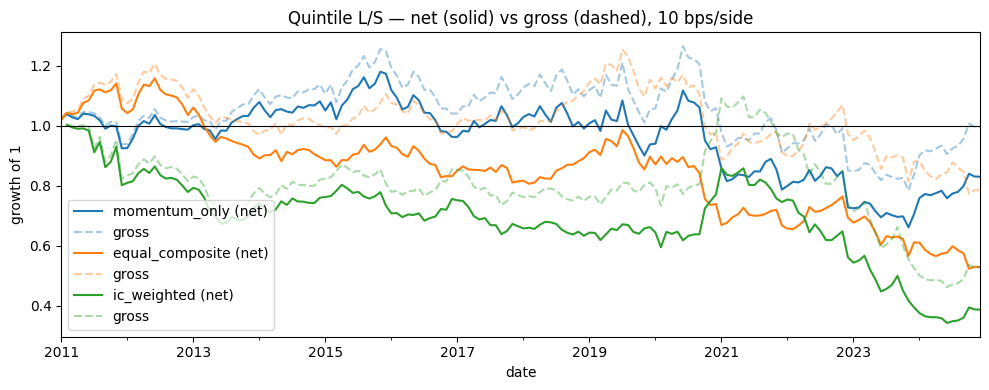

In [5]:
fig, ax = plt.subplots()
net_books = {}
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for (name, fz), col in zip(books.items(), colors):
    bk = long_short_book(fz, fwd, q=0.2, cost_per_side=0.0010)
    net_books[name] = bk["net"]
    (1 + bk["net"]).cumprod().plot(ax=ax, color=col, label=f"{name} (net)")
    (1 + bk["gross"]).cumprod().plot(ax=ax, color=col, ls="--", alpha=0.4)
ax.axhline(1, color="k", lw=0.8); ax.legend()
ax.set(ylabel="growth of 1", xlabel="date",
       title="Quintile L/S — net (solid) vs gross (dashed), 10 bps/side")
plt.tight_layout()
plt.savefig(PLOTS / "03_net_equity.png", dpi=110, bbox_inches="tight"); plt.show()

## 5. The honest test battery — PSR & Deflated Sharpe

A Sharpe is meaningless without (a) confidence it is not a small-sample / non-normal fluke
(**Probabilistic Sharpe**) and (b) a penalty for having *searched* over factors and configs
(**Deflated Sharpe**, AFML Ch. 14). We deflate against the spread of Sharpes our own search produced
and an honest trial count (3 factors × a few weighting/cost choices ≈ 12).

In [6]:
# variance of Sharpes across the strategies we actually tried -> deflation benchmark
trial_sharpes = [sharpe_ratio(long_short_book(fz, fwd, cost_per_side=0.0010)["net"].values)
                 for fz in [*neutral.values(), ew_composite, combo]]
sr_trials_std = float(np.std(trial_sharpes))
N_TRIALS = 12

rows = []
for name, net in net_books.items():
    r = net.values
    rows.append({"book": name,
                 "sharpe_ann": sharpe_ratio(r) * np.sqrt(12),
                 "PSR(>0)": probabilistic_sharpe_ratio(r),
                 "DSR": deflated_sharpe_ratio(r, n_trials=N_TRIALS, sr_trials_std=sr_trials_std)})
verdict = pd.DataFrame(rows).set_index("book")
print(f"deflation: n_trials={N_TRIALS}, sr_trials_std={sr_trials_std:.3f}")
verdict.round(3)

deflation: n_trials=12, sr_trials_std=0.057


,sharpe_ann,PSR(>0),DSR
book,,,
momentum_only,-0.0650,0.4040,0.0710
equal_composite,-0.3880,0.0670,0.0030
ic_weighted,-0.4580,0.0440,0.0020


## 6. Findings — the verdict

- **No construction survives costs.** Net of a realistic 10 bps/side, every book is *negative*:
  momentum-only ≈ **−0.7%/yr**, equal-composite ≈ **−4%/yr**, IC-weighted ≈ **−6%/yr**. The best gross
  book (momentum, ~+0.6%/yr) is already too thin to clear its ~1.1%/yr cost drag.
- **Smarter weighting made it worse, not better.** The look-ahead-free IC-weighted combo *loses most*.
  The reason is subtle and worth stating: **IC weighting optimises rank correlation, but a quintile
  book lives in the tails** — and the high-IC factor (reversal) has *no tail edge* (nb02), so weighting
  toward it buys turnover without return. Rank-IC is not tradable P&L.
- **The statistics reject all three.** Annualised net Sharpes are ≤ 0; Probabilistic Sharpe ≈ 0 and
  **Deflated Sharpe ≈ 0** (needs ~0.95) — exactly what you should see when there is no skill and you
  have searched a handful of configs.
- **Why no edge here, honestly:** (1) price-only factors on **large, efficient S&P 500 names** are the
  most arbitraged corner of the market; (2) **survivorship bias** flatters even these losing numbers;
  (3) the only classic anomaly with a clean signal in-sample (low-vol) had the **wrong sign** in this
  regime. A real edge would more likely come from *fundamentals/quality*, a *broader/less-liquid
  universe*, or *point-in-time data* — not from re-weighting three exhausted price signals.
- **The deliverable is the rejection.** A pipeline that builds factors, combines them without leakage,
  charges costs, and refuses to believe the equity curve until the deflated Sharpe clears — and here it
  correctly says *no edge*. That is the same discipline as project 02, now on the cross-sectional
  equity side.

**Where a follow-up would look:** add a **fundamental quality/value factor** (SimFin/FMP free tier),
widen to a **mid-cap / point-in-time** universe to kill survivorship bias, and meta-label entries
rather than trade the raw rank.